# Actividad en Clase: Feature Engineering

Andrés Jaramillo - A01029079

Pedro Mauri Mtz - A01029143

### Librerías utilizadas:

- Pandas.
- NumPy.
- Matplot.
- Seaborn.

In [2]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))

### Configuración de visualización de las gráficas.

In [3]:
sns.set(style = 'whitegrid', palette = 'muted')
plt.rcParams['figure.figsize'] = (10,6)

# Analysis Exploration



### Lectura del archivo "orders-1.csv"

In [4]:
df = pd.read_csv(ROOT + "/Datasets/orders-1.csv")

### Impresión de las primeras 5 muestras guardadas en el tensor del dataset.

El contexto del data-set parece tratarse de un registro de ordenes de servicio a domicilio de diversas tiendas.

Se puede visualizar las siguientes características del data-set:

- Features:
1. ID de la orden (order_id).
2. ID de la tienda (store_id).
3. Distancia al usuario (to_user_distance).
4. Elevación al usuario (to_user_elevation).
5. Gnancia total (total_earning).
6. Fecha y hora de creación de orden (created_at).

- Tag:
1. Booleano en forma de número, de asignación de orden (taken).

In [5]:
df.head()

,order_id,store_id,to_user_distance,to_user_elevation,total_earning,created_at,taken
0,14364873,30000009,2.478101,-72.719360,4200,2017-09-07T20:02:17Z,0
1,14370123,30000058,0.451711,37.754761,4200,2017-09-07T20:13:16Z,0
2,14368534,900003684,2.026072,207.191162,4000,2017-09-07T20:07:23Z,0
3,14370258,900014452,2.671432,1.722656,4400,2017-09-07T20:15:19Z,1
4,14369923,900014085,0.965496,117.429199,3450,2017-09-07T20:12:14Z,1


# Especificaciones del dataset.

1. **Dimensión:** Se puede ver que hay 6 características y 1 etiqueta (7 columnas). Y 146,987 muestras distintas (146,987 filas).

2. **Tipos de datos en el data-set:** Podemos ver que todos excepto uno de los 7 tipos de variables son 'int64' y 'float64', por lo que son puros números. Con excepción de las fechas de creción de la orden (created_at), el cual es un 'object' compuesto por la hora y fecha completas (horas, minutos, segundos, día, mes y año).

3. **Valores Null:** Se buscaron datos con valores 'vacios / null' en alguna característica, pero no se encontró ninguno (No hay valores 'null' en el data-set).

4. **Estadísticas descriptivas:** La función 'describe()' recauda diversas características de las variables encontradas en el data-set. (count, unique, top, freq, mean, std, min, 25%, 50%, 75%, max). La mayoría de estas características no son útilies a la hora de darnos información importante, para diversas variables específicas. Pero las más relevantes son:
- El 'count' de cada variable es 146,987.
- Para las fechas de 'created_at'; 'uninque' tiene un total de 26,914 fechas únicas, y 'top' tiene "2017-09-23 19:06:05" como fecha que más se repite en el data-set.
- Y que en 'total_earning' tenemos como 'mean' 5,358.64, y que el 'max' es 108,200 como el valor más alto.

In [6]:
print("Dimensiones del dataset:", df.shape)

print("\nTipos de datos:")
print(df.dtypes)

print("\nValores nulos por columna:")
print(df.isnull().sum())

print("\nEstadísticas descriptivas:")
print(df.describe(include = 'all'))

Dimensiones del dataset: (146987, 7)

Tipos de datos:
order_id               int64
store_id               int64
to_user_distance     float64
to_user_elevation    float64
total_earning          int64
created_at               str
taken                  int64
dtype: object

Valores nulos por columna:
order_id             0
store_id             0
to_user_distance     0
to_user_elevation    0
total_earning        0
created_at           0
taken                0
dtype: int64

Estadísticas descriptivas:
            order_id      store_id  to_user_distance  to_user_elevation  \
count   1.469870e+05  1.469870e+05     146987.000000      146987.000000   
unique           NaN           NaN               NaN                NaN   
top              NaN           NaN               NaN                NaN   
freq             NaN           NaN               NaN                NaN   
mean    1.507718e+07  7.580708e+08          1.501015          26.899130   
std     4.750119e+05  3.214280e+08          0.845

# Distribución de ids ordenes. 'order_id'

En la siguiente gráfica se plasma la cantidad de ids que hay en ciertos rangos de 25,000 ids entre la id de valor más bajo y más alto.
Es decir, cuantas ids hay entre el número 14250000 y 14500000, y así susecivamente hasta llegar a 15652152 (id más alta).

Se puede ver que la mayor concentración de ids tienen un valor de 1528000 aproximadamente, tenindo más de 4000 ids con un valor cercano.

Sin embargo, pese a haber varios picos en la distribución, consideramos que esta decentemente balanceada, etre el la id más baja y la más alta.

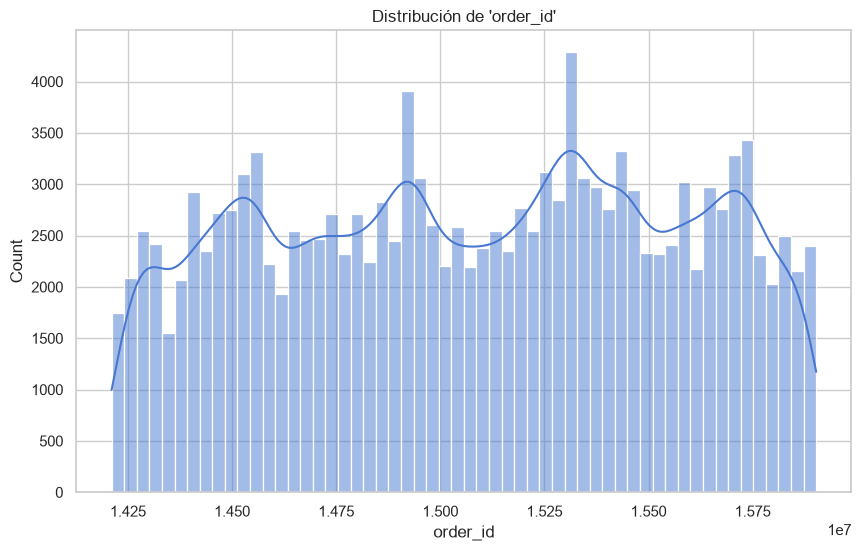

In [7]:
sns.histplot(df['order_id'], kde = True)
plt.title("Distribución de 'order_id'")
plt.show()

# Distribución de ids de tiendas. 'store_id'

[texto]

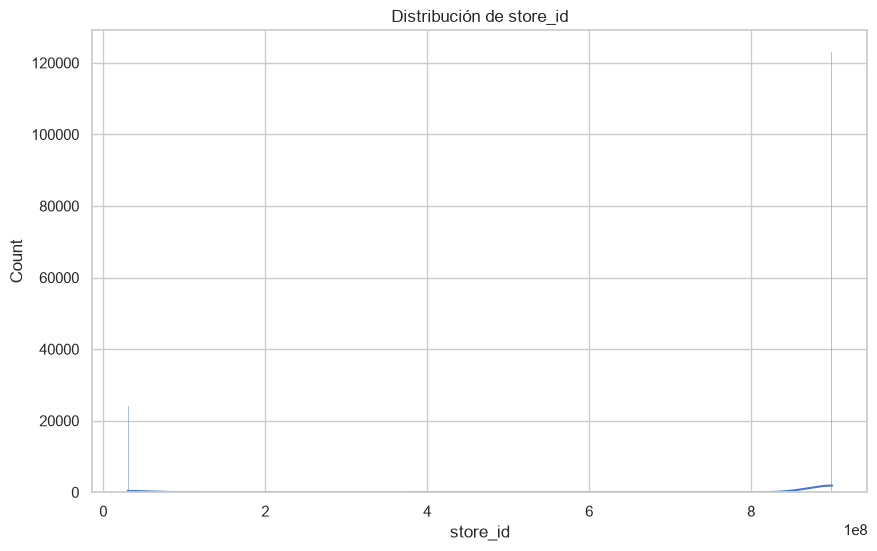

In [8]:
sns.histplot(df['store_id'], kde = True)
plt.title("Distribución de store_id")
plt.show()

# Distribución de distancias a usuarios. 'to_user_distance'

En esta gráfica se puede apreciar que la mayoría de las distancias de los usuarios a las tiendas se encunetran aproximadamente al valor de 1, y que la distancia más alta se acerca a 3.5.
Se asume que la distancia esta medida en kilometros, sin embargo no se sabe con certeza.

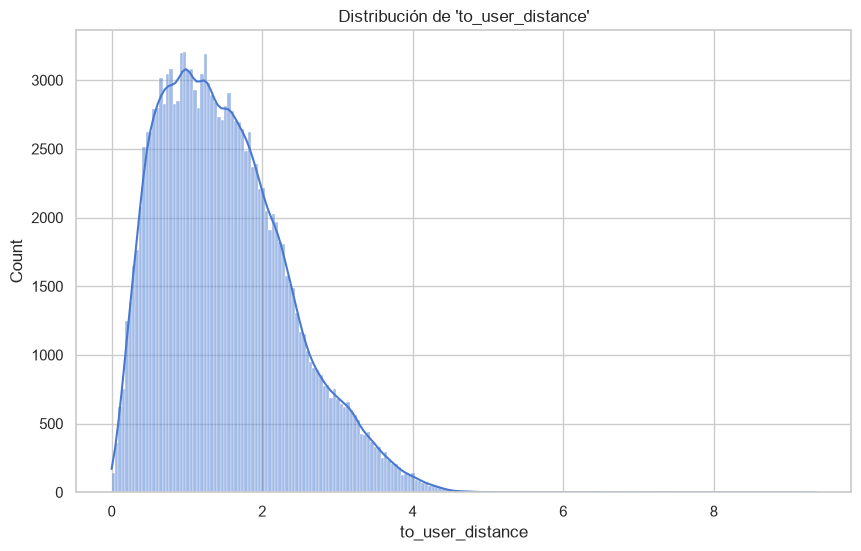

In [9]:
sns.histplot(df['to_user_distance'], kde = True)
plt.title("Distribución de 'to_user_distance'")
plt.show()

# Distribución de elevaciones a usuarios. 'to_user_elevation'

Por otra parte, en la gráfica de las elevaciones entre las tiendas y los usuarios se puede ver que la mayoría se acerca bastante al valor de 0, mientras que la elevación más baja se acerca -250, y la más alta a 280 aproximadamente.

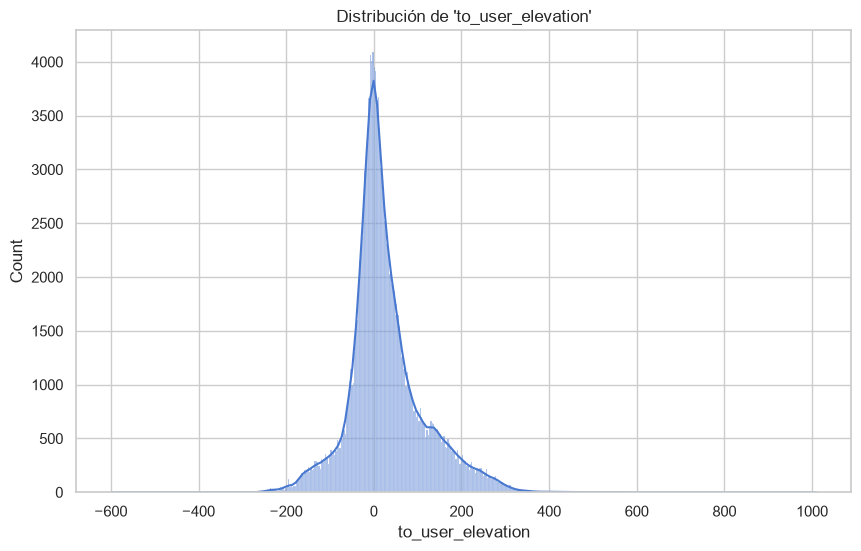

In [10]:
sns.histplot(df['to_user_elevation'], kde = True)
plt.title("Distribución de 'to_user_elevation'")
plt.show()

# Distribución de ganancias totales. 'total_earning'

La distribución de ganancias totales tiene una particularidad, la mayoría de las ganancias se ubican entre los valores de 1500 a 10000, con un pico de 20000 muestras en un valor aproximado de 2000. La peculiaridad es que hay una sola muestra con un valor de aproximado de 150000, el cual tiene una gran diferencia con la muestra con el segundo valor más alto.

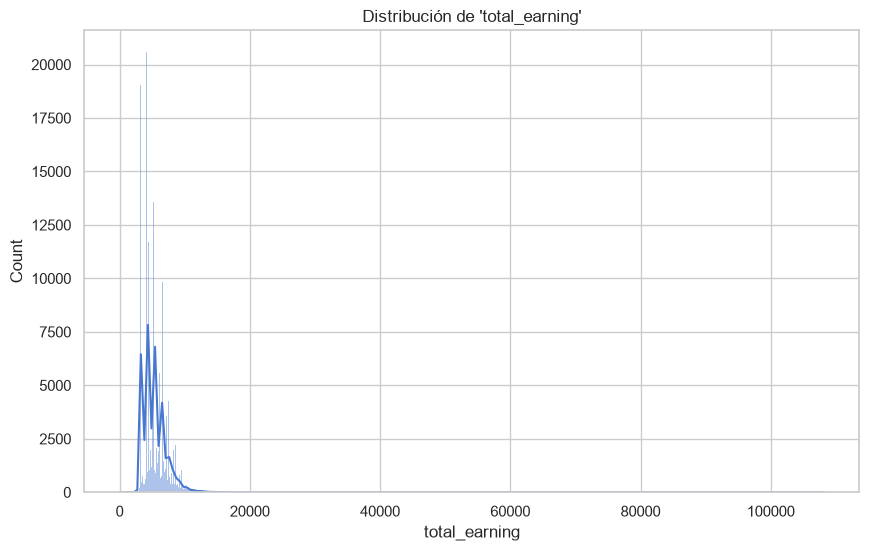

In [11]:
sns.histplot(df['total_earning'], kde = True)
plt.title("Distribución de 'total_earning'")
plt.show()

# Distribución de fechas de creación de orden. 'created_at'

La distribución de las fechas de creación se ve bastante consistente, eso significa que la cantidad de ordenes creadas no cambia muCho dependiendo del día. Lo único relevante es que de manera general, la cantidad de ordenes por día se ha visto ligeramente reducida acercandonos al futuro.

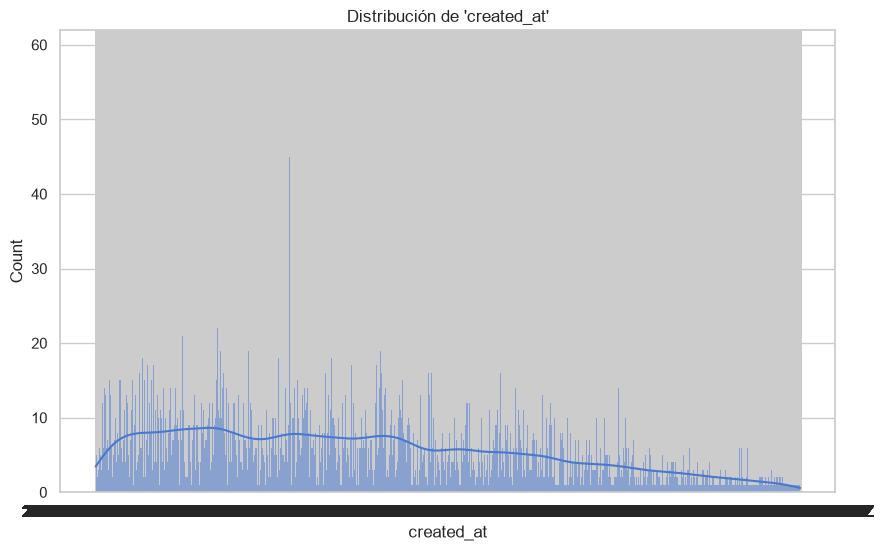

In [13]:
sns.histplot(df['created_at'], kde = True)
plt.title("Distribución de 'created_at'")
plt.show()

# Distribución de asignaciones de orden. 'taken'

En esta gráfica se puede visualizar la distribución entre las únicas dos opciones de la variable 'taken'. Es decir, la cantidad de muetras donde 'taken' tiene un valor de 0s o de 1s.

Es prudente decir que el data-set esta muy desbalanciado, ya que la diferencia entre las cantidades de las dos etiquetas es demasiado grande. Hay un número de 117,500 aproximadamente de muestras con valores de 1s. Mientras que con valores de 0s hay 10,000 aproximadamente.

Esto implica que el data-set no es de muy buena calidad para un entrenamiento, ya que lo ideal es que el número de muestras entre las dos "opciones" de etiquetas se acerquen. Es decir, que haya casi el mismo número de 0s que de 1s en las muestras de la variable 'taken'.

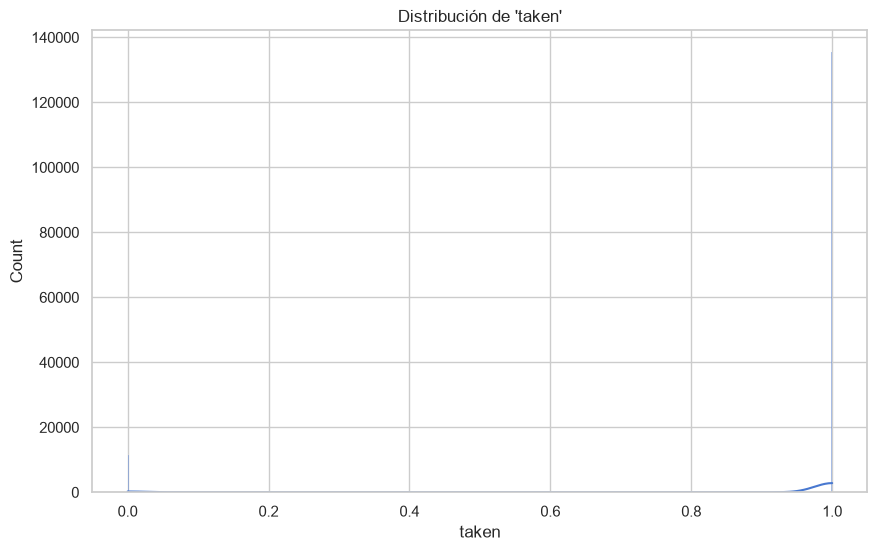

In [14]:
sns.histplot(df['taken'], kde = True)
plt.title("Distribución de 'taken'")
plt.show()

## Transformación de los datos

Análisis de: 'creatd_at' y 'taken.'

In [15]:
df['created_at'] = pd.to_datetime(df['created_at'], utc = True)

Separación de composición de la fecha completa de 'created_at'.

In [16]:
df['year'] = df['created_at'].dt.year
df['month'] = df['created_at'].dt.month
df['day'] = df['created_at'].dt.day
df['hour'] = df['created_at'].dt.hour
df['weekday'] = df['created_at'].dt.day_name()
df['is_weekend'] = df['weekday'].isin([5, 6]).astype(int)
df['is_peak_hour'] = df['hour'].between(12, 14) | df['hour'].between(18, 20)
df['is_peak_hour'] = df['is_peak_hour'].astype(int)

### Frecuencia de las órdenes según el día de la semana.

De manera básica, se puede ver que los domingos es el día en el que más ordenes se han creado, mientras que el lunes es el día en el que menos.
Mientras más acercados al final de la semana estemos, más órdenes serán creadas. Con la excepción del martes y miercoles.

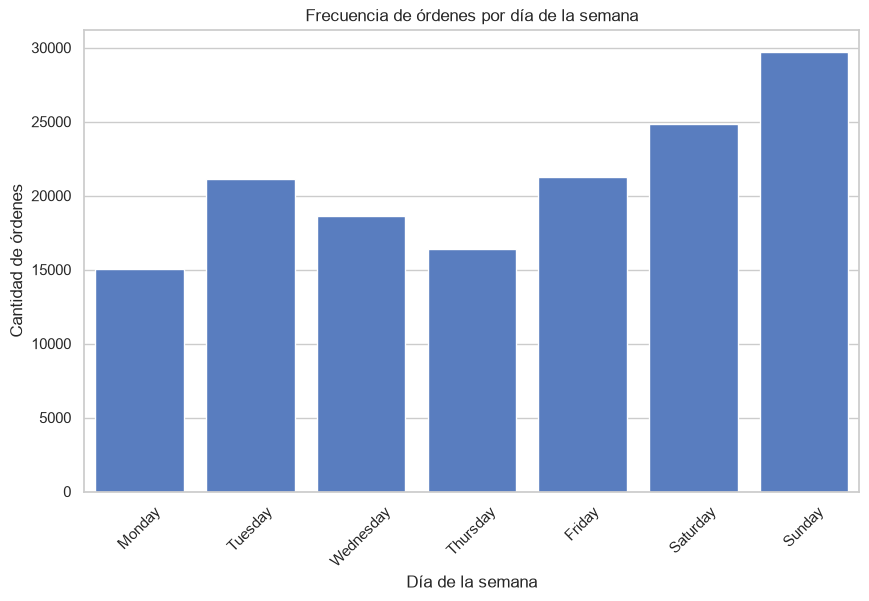

In [17]:
order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

sns.countplot(data = df, x = 'weekday', order = order)
plt.title("Frecuencia de órdenes por día de la semana")
plt.xlabel("Día de la semana")
plt.ylabel("Cantidad de órdenes")
plt.xticks(rotation = 45)
plt.show()

### Frecuencia de las ordenes según el número del día en el mes.

Como se puede visualizar, normalmente los fines de semana cada 10 ~ días un pico de pedidos.

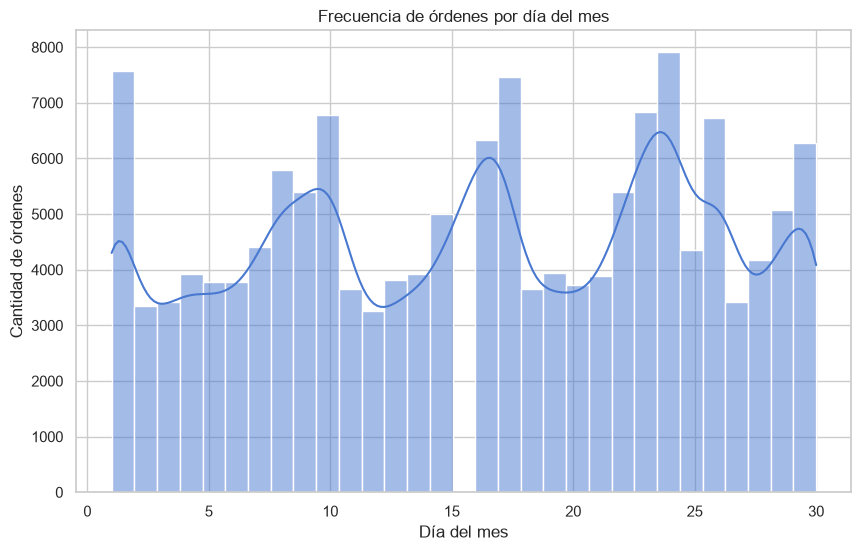

In [18]:
sns.histplot(df['day'], bins = 31, kde = True)
plt.title("Frecuencia de órdenes por día del mes")
plt.xlabel("Día del mes")
plt.ylabel("Cantidad de órdenes")
plt.show()

### Frecuencia de órdenes por hora del día

Como podemos ver hay grandes picos de pedidos al mediodía y casi cercanos a las 7 p.m, esto muestra posibles momentos de hora de comida y cena.

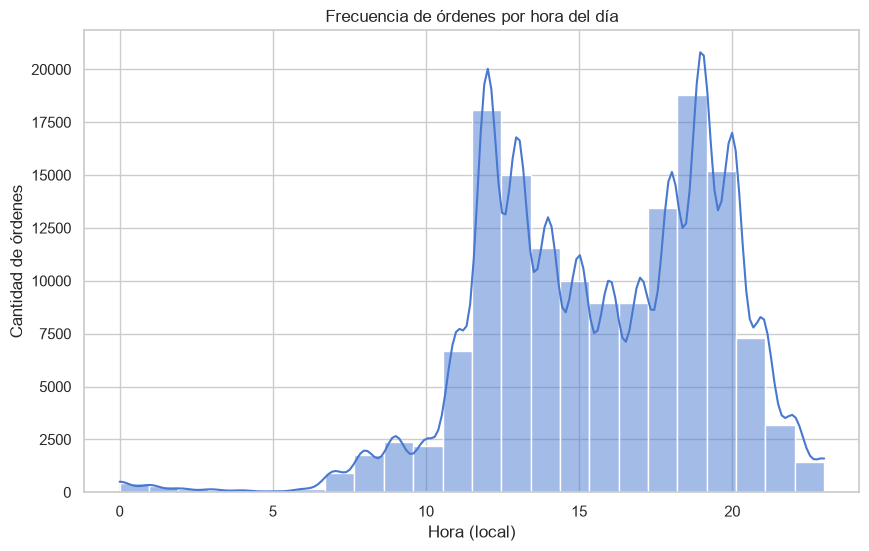

In [19]:
sns.histplot(df['hour'], bins = 24, kde = True)
plt.title("Frecuencia de órdenes por hora del día")
plt.xlabel("Hora (local)")
plt.ylabel("Cantidad de órdenes")
plt.show()

### Ratio de taken
Aquí podemos ver que hay un ratio de 92.12% de taken vs 7.87% de pedidos no tomados, entonces hay un gran sesgo.

In [20]:
taken_rate = df['taken'].value_counts(normalize = True) * 100
print(taken_rate)

taken
1    92.121752
0     7.878248
Name: proportion, dtype: float64


# Feature Engineering

Se generaron nuevas variables derivadas para mejorar la capacidad predictiva del modelo:

- **Conversión de unidades**
  - `to_user_elevation` → convertido a kilómetros

- **Ratios útiles**
  - `elevation_per_km` → elevación por km recorrido
  - `earning_per_km` → ganancia por kilómetro
  - `earning_per_m_elevation` → ganancia por metro de elevación
  - `slope_ratio` → relación entre elevación y distancia (pendiente)

- **Transformaciones logarítmicas**
  - `distance_log` → log1p de la distancia (reduce colas largas)
  - `earning_log` → log1p de la ganancia
  - `earning_per_distance_log` → ganancia por distancia en escala logarítmica

- **Combinación ponderada**
  - `weighted_distance` → distancia ajustada por pendiente (`slope_ratio`)

In [21]:
df['to_user_elevation'] = df['to_user_elevation'] / 1000 # To KM

In [22]:
df['elevation_per_km'] = df['to_user_elevation'] / (df['to_user_distance'] + 1e-5)
df['distance_log'] = np.log1p(df['to_user_distance']) # log(1 + x) suaviza colas largas

In [23]:
df['earning_per_km'] = df['total_earning'] / (df['to_user_distance'] + 1e-5)
df['earning_per_m_elevation'] = df['total_earning'] / (df['to_user_elevation'] * 1000 + 1e-5)

In [24]:
df['slope_ratio'] = df['to_user_elevation'] / (df['to_user_distance'] + 1e-5)

In [25]:
df['weighted_distance'] = df['to_user_distance'] * (1 + df['slope_ratio'])

In [26]:
df['earning_log'] = np.log1p(df['total_earning'])

In [27]:
df['earning_per_distance_log'] = df['total_earning'] / (df['distance_log'] + 1e-5)

## Train/Test Dataset creation

Para dividir el train/test se hizo lo siguiente:
- **Train:** desde `2017-09-05` hasta `2017-09-27`
- **Test:** desde `2017-09-28` hasta `2017-10-04`

In [28]:
df['date'] = df['created_at'].dt.date

In [29]:
train_start = pd.to_datetime('2017-09-05').date()
train_end   = pd.to_datetime('2017-09-27').date()
test_start  = pd.to_datetime('2017-09-28').date()
test_end    = pd.to_datetime('2017-10-04').date()

In [30]:
mask_train = (df['date'] >= train_start) & (df['date'] <= train_end)
mask_test  = (df['date'] >= test_start) & (df['date'] <= test_end)

In [31]:
df_train = df.loc[mask_train].copy()
df_test  = df.loc[mask_test].copy()

In [32]:
print(f"Train rows: {len(df_train)}, Test rows: {len(df_test)}")

Train rows: 113192, Test rows: 33795


In [33]:
y_train = df_train['taken']
y_test  = df_test['taken']

In [34]:
cols_to_drop = ['created_at', 'weekday', 'date', 'taken']
X_train = df_train.drop(columns=[c for c in cols_to_drop if c in df_train.columns])
X_test  = df_test.drop(columns=[c for c in cols_to_drop if c in df_test.columns])

In [35]:
print("X_train:", X_train.shape, "| y_train:", y_train.shape)
print("X_test :", X_test.shape,  "| y_test :", y_test.shape)

X_train: (113192, 19) | y_train: (113192,)
X_test : (33795, 19) | y_test : (33795,)


In [36]:
print("Train fechas:", df_train['date'].min(), "->", df_train['date'].max())
print("Test  fechas:", df_test['date'].min(),  "->", df_test['date'].max())

Train fechas: 2017-09-05 -> 2017-09-27
Test  fechas: 2017-09-28 -> 2017-10-04


# Riesgos de Data Leakage y como atacarlas

Tener cuidado con características derivadas del resultado final (como promedios globales, variables de performance acumulada o etiquetas codificadas indirectamente) o timestamps mal utilizados que filtren conocimiento del futuro.

Para atacarlos es importante:
1) separar primero train/test,
2) aplicar toda transformación estadística solo con datos de entrenamiento (scalers, imputadores, encoders, feature selection),
3) revisar manualmente que ninguna feature use información del futuro o esté “demasiado correlacionada” con la etiqueta por diseño,
4) validar con una cross-validation temporal o adecuada al dominio para simular el entorno real de predicción.

# Entrenar Modelo

Se implementó un **modelo baseline** utilizando un `DecisionTreeClassifier` sin hiperparámetros ajustados (solo con `random_state` para reproducibilidad).

In [37]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

# Modelo baseline
tree_model = DecisionTreeClassifier(
    random_state=42,
    max_depth=None  # puedes limitarlo más adelante
)

# Entrenar
tree_model.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

Como modelo final se utilizó **XGBoost (`XGBClassifier`)** porque es un algoritmo que trabaja batante bien con este tipo de datos y relaciones complejas entre variables.

In [38]:
from xgboost import XGBClassifier

# Modelo XGBoost
xgb_model = XGBClassifier(
    n_estimators = 200,        # número de árboles
    learning_rate = 0.1,       # tasa de aprendizaje
    max_depth = 5,             # profundidad de cada árbol
    subsample = 0.8,           # fracción de muestreo
    colsample_bytree = 0.8,    # fracción de columnas
    random_state = 42,
    use_label_encoder = False,
    eval_metric = 'logloss'
)

# Entrenar
xgb_model.fit(X_train, y_train)


c:\Users\pedro\Documents\Documentos Tec\Semestre_7_Concentracion_IA\Advanced_IA_Implementation\env\Lib\site-packages\xgboost\training.py:200: UserWarning: [20:23:46] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:794: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",'logloss'
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


# Probar Modelo

### Resultados baseline
- **Accuracy:** 0.61
- **Precision:** 0.91
- **Recall:** 0.63
- **F1-score:** 0.74

In [39]:
# Predicciones
y_pred_tree = tree_model.predict(X_test)

# Evaluación
print("=== Árbol de Decisión (Baseline) ===")
print("Accuracy :", accuracy_score(y_test, y_pred_tree))
print("Precision:", precision_score(y_test, y_pred_tree))
print("Recall   :", recall_score(y_test, y_pred_tree))
print("F1-score :", f1_score(y_test, y_pred_tree))

# Matriz de confusión
print("\nMatriz de Confusión:")
print(confusion_matrix(y_test, y_pred_tree))

# Resumen completo
print("\nReporte de Clasificación:")
print(classification_report(y_test, y_pred_tree))

=== Árbol de Decisión (Baseline) ===
Accuracy : 0.6146767273265276
Precision: 0.9190732351830879
Recall   : 0.6326988045738046
F1-score : 0.7494612898260735

Matriz de Confusión:
[[ 1296  1715]
 [11307 19477]]

Reporte de Clasificación:
              precision    recall  f1-score   support

           0       0.10      0.43      0.17      3011
           1       0.92      0.63      0.75     30784

    accuracy                           0.61     33795
   macro avg       0.51      0.53      0.46     33795
weighted avg       0.85      0.61      0.70     33795



### Resultados principales
- **Accuracy:** 0.91
- **Precision:** 0.91
- **Recall:** 0.99
- **F1-score:** 0.95

In [40]:
# Predicciones
y_pred_xgb = xgb_model.predict(X_test)

# Evaluación
print("=== XGBoost ===")
print("Accuracy :", accuracy_score(y_test, y_pred_xgb))
print("Precision:", precision_score(y_test, y_pred_xgb))
print("Recall   :", recall_score(y_test, y_pred_xgb))
print("F1-score :", f1_score(y_test, y_pred_xgb))

# Matriz de confusión
print("\nMatriz de Confusión:")
print(confusion_matrix(y_test, y_pred_xgb))

# Reporte detallado
print("\nReporte de Clasificación:")
print(classification_report(y_test, y_pred_xgb))

=== XGBoost ===
Accuracy : 0.9101642254771416
Precision: 0.9129904149550515
Recall   : 0.996329261954262
F1-score : 0.9528410326509056

Matriz de Confusión:
[[   88  2923]
 [  113 30671]]

Reporte de Clasificación:
              precision    recall  f1-score   support

           0       0.44      0.03      0.05      3011
           1       0.91      1.00      0.95     30784

    accuracy                           0.91     33795
   macro avg       0.68      0.51      0.50     33795
weighted avg       0.87      0.91      0.87     33795



## Slicing test

El slicing evalúa cómo se comporta el modelo **por clase**, en lugar de ver solo el accuracy global. El modelo XGBoost es **muy bueno prediciendo la clase 1**, pero **casi no detecta la clase 0**.

In [41]:
from sklearn.metrics import accuracy_score, recall_score, f1_score

def slicing_test(y_true, y_pred, clase):
    mask = (y_true == clase)
    acc_slice = accuracy_score(y_true[mask], y_pred[mask])   # accuracy dentro del slice
    rec = recall_score(y_true, y_pred, pos_label=clase)      # recall normal
    f1  = f1_score(y_true, y_pred, pos_label=clase)          # f1 normal
    return acc_slice, rec, f1, mask.sum()

# --- Baseline ---
print("=== Slicing Test - Baseline (Árbol) ===")
for cls in [0, 1]:
    acc, rec, f1, support = slicing_test(y_test, y_pred_tree, cls)
    print(f"Clase {cls} | Soporte: {support} | Slice Accuracy: {acc:.4f} | Recall: {rec:.4f} | F1: {f1:.4f}")

# --- XGBoost ---
print("\n=== Slicing Test - XGBoost ===")
for cls in [0, 1]:
    acc, rec, f1, support = slicing_test(y_test, y_pred_xgb, cls)
    print(f"Clase {cls} | Soporte: {support} | Slice Accuracy: {acc:.4f} | Recall: {rec:.4f} | F1: {f1:.4f}")

=== Slicing Test - Baseline (Árbol) ===
Clase 0 | Soporte: 3011 | Slice Accuracy: 0.4304 | Recall: 0.4304 | F1: 0.1660
Clase 1 | Soporte: 30784 | Slice Accuracy: 0.6327 | Recall: 0.6327 | F1: 0.7495

=== Slicing Test - XGBoost ===
Clase 0 | Soporte: 3011 | Slice Accuracy: 0.0292 | Recall: 0.0292 | F1: 0.0548
Clase 1 | Soporte: 30784 | Slice Accuracy: 0.9963 | Recall: 0.9963 | F1: 0.9528
